# Projet - Deep Learning

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import seaborn as sns
import ipywidgets as widgets

## Contexte

Le diabète fait partie des maladies chroniques les plus courantes aux États-Unis et touche chaque année des millions de personnes. Cette affection sérieuse se traduit par une mauvaise régulation du sucre dans le sang, ce qui peut, à long terme, réduire la qualité de vie et même l’espérance de vie. Au moment de la digestion, les aliments se transforment en sucres qui passent dans le sang. Cela incite le pancréas à produire de l’insuline, une hormone qui permet aux cellules d’utiliser ces sucres comme source d’énergie. Dans le cas du diabète, soit l’organisme ne produit pas assez d’insuline, soit il réagit mal.

L’excès prolongé de sucre dans le sang augmente les risques de complications graves : maladies cardiovasculaires, perte de la vue, amputations ou encore insuffisance rénale. Même si le diabète ne se guérit pas, il est possible d’en limiter les effets grâce à la perte de poids, à une alimentation adaptée, à une activité physique régulière et à un suivi médical approprié. Plus le diagnostic est posé tôt, plus il est possible d’agir efficacement. C’est pour cette raison que les outils de prédiction du risque de diabète représentent un enjeu important de santé publique.

L’ampleur du phénomène est frappante. Selon les Centres pour le contrôle et la prévention des maladies (CDC) en 2018, 34,2 millions d’Américains vivaient avec un diabète, et 88 millions étaient prédiabétiques. Une personne diabétique sur cinq n’en avait pas conscience, et la grande majorité des personnes prédiabétiques ignorait également leur situation. Le diabète de type 2, la forme la plus fréquente, est influencé par de nombreux facteurs : âge, niveau d’études, revenus, zone géographique, origine ethnique ou encore conditions sociales de vie. Les populations les plus défavorisées sont souvent les plus touchées.

La maladie représente aussi un poids financier immense : le coût du diabète diagnostiqué est estimé à environ 327 milliards de dollars par an, et si l’on inclut le diabète non diagnostiqué et le prédiabète, on approche les 400 milliards de dollars.

**Objectifs :**

Nous sommes chargés de construire un modèle de classification binaire permettant de prédire la probabilité qu’une personne soit diabétique à partir des données médicales issues de l’enquête diabetes_binary_health_indicators_BRFSS201 (BRFSS 2015).

Notre objectif ultime est de maximiser la métrique ROC AUC sur un jeu de test non étiqueté.
En parallèle, nous adopterons une approche MLOps (versioning des données, traçabilité et automatisation des traitements) et nous travaillerons en mode Scrum, selon trois sprints, livrables à chaque itération.

## Présentation du jeu de données

Le Système de surveillance des facteurs de risque comportementaux (BRFSS) est une enquête téléphonique annuelle menée par les Centres pour le contrôle et la prévention des maladies (CDC) sur la santé. Chaque année, cette enquête recueille les réponses de plus de 400 000 Américains sur leurs comportements à risque pour la santé, leurs maladies chroniques et leur recours aux services de prévention. Elle est réalisée chaque année depuis 1984. Pour ce projet, nous avons utilisé un fichier CSV des données disponibles sur [Kaggle](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) pour l'année 2015. Ce jeu de données contient les réponses de 253 680 personnes et comporte 22 variables. Ces variables correspondent soit à des questions posées directement aux participants, soit à des variables calculées à partir de leurs réponses individuelles.

Les variables du dataset sont :
- **Diabetes_binary :** Objectif de l’étude : indique si la personne est diabétique (1 = Oui, 0 = Non).

- **HighBP :** Indique si le sujet souffre d’hypertension artérielle. 
- **HighChol :** Le sujet a un taux de cholestérol élevé. 
- **CholCheck :** Le sujet a effectué un contrôle du cholestérol dans les 5 dernières années. 
- **BMI :** Indice de masse corporelle. 
- **Smoker :** Le sujet a fumé plus de 100 cigarettes au cours de sa vie. 
- **Stroke :** Le sujet a déjà eu un AVC. 
- **HeartDiseaseorAttack :** Le sujet a déjà eu une maladie coronarienne ou un infarctus du myocarde. 
- **PhysActivity :** Le sujet a pratiqué une activité physique au cours des 30 derniers jours (hors travail). 
- **Fruits :** Le sujet consomme des fruits au moins une fois par jour. 
- **Veggies :** Le sujet consomme des légumes au moins une fois par jour. 
- **HvyAlcoholConsump :** Forte consommation d’alcool (hommes ≥ 14 verres/semaine, femmes ≥ 7). 
- **AnyHealthcare :** Le sujet bénéficie d’une couverture santé (assurance ou mutuelle). 
- **NoDocbcCost :** Le sujet n’a pas consulté un médecin dans les 12 derniers mois à cause du coût. 
- **GenHlth :** État de santé général (1 = excellent, 2 = très bon, 3 = bon, 4 = moyen, 5 = mauvais). 
- **MentHlth :** Nombre de jours de mauvaise santé mentale sur les 30 derniers jours. 
- **PhysHlth :** Nombre de jours de maladie ou blessure sur les 30 derniers jours. 
- **DiffWalk :** Difficulté à marcher ou monter des escaliers. 
- **Sex :** Sexe du sujet (0 = Femme, 1 = Homme). 
- **Age :** Tranche d’âge (1 = 18–24, …, 13 = 80+). 
- **Education :** Niveau d’éducation (1 = jamais scolarisé, …). 
- **Income :** Niveau de revenu (1 < 10k$, …, 8 < 75k$).


### Séparation des données

Il est primordial de séparer les données en deux catégories bien distinctes :
- Variable cible : elle représente le résultat que l’on cherche à prédire ou à expliquer à l’aide du modèle.

- Variables explicatives : elles correspondent aux variables utilisées pour prédire, expliquer ou décrire la variable cible.

Dans ce contexte, la seule variable cible, c'est-à-dire celle que nous allons de voir prévoir dans notre projet sera **Diabetes_binary**.

Tout le reste des variables sont des variables explicatives. 

On distingue principalement deux types de variables : les variables quantitatives et les variables qualitatives. Cette distinction est essentielle pour choisir les méthodes d’analyse et de modélisation adaptées.

Une variable quantitative (ou numérique) correspond à une information mesurable qui s’exprime par un nombre (ex: Age, poids, température, supercifie, ...). Dans notre contexte les variables sont considérés comme quantitative continue (variable qui prend un infini de valeurs réelles à l'intérieur d'un interval donné) :
- BMI
- MenHlth
- PhysHlth

Une variable qualitative (ou catégorielle) décrit une caractéristique non numérique. Elle représente des catégories ou des états. Il y a 2 types de variables qualitatives : qualitative nominale (étiquetage, binaire) et qualitative ordinale (données définies dans une relation d'ordre entre différentes catégories possibles). Variables qualitatives nominales :
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- Smoker
- Stroke
- HeartDiseaseorAttack 
- PhysActivity 
- Fruits
- Veggies 
- HvyAlcoholConsump 
- AnyHealthcare
- NoDocbcCost
- DiffWalk
- Sex 

Variables ordinales :
- GenHlth
- Age
- Income
- Education

### Variables sensibles 

À des fins d’anonymisation et de limitation des biais, nous avons choisi de retirer certaines variables non essentielles à la prédiction du diabète.
- **Income :** le niveau de revenu peut être indirectement lié au diabète (accès aux soins, alimentation), mais nous choisissons de l’exclure afin d’éviter d’introduire des biais socio-économiques dans le modèle.
- **Education :** de même, le niveau d’éducation peut influencer certains comportements de santé, mais il n’est pas un facteur médical direct. Nous le retirons afin de limiter les biais et de conserver un modèle centré sur des variables de santé.

Le dataset contient également certaines variables pouvant être considérées comme subjectives. En effet, ces variables reposent sur des auto-évaluations des individus, ce qui peut introduire des biais liés à la perception personnelle ou à l’état mental.
- **GenHlth**
- **MenHlth**
- **PhysHlth**

### Scission des données (Train/Test/Validation)

Afin d'entrainer au mieux notre modèle avec nos donnéees, nous allons séparer notre dataset en 3 sous-dataset.

- **Dataset d'entrainement :** Ce jeu de données est utilisé pour entraîner le modèle. Il permet au modèle d’apprendre les relations et les patterns présents dans les données.
- **Dataset de validation :** Ce jeu de données est utilisé pendant l’entraînement pour évaluer les performances du modèle de manière intermédiaire. Il permet d’ajuster les hyperparamètres et de choisir le meilleur modèle, tout en limitant le surapprentissage (overfitting).
- **Dataset de test :** Ce jeu de données est utilisé uniquement à la fin du processus. Il permet d’évaluer les performances finales du modèle sur des données qu’il n’a jamais vues. On compare alors les valeurs prédites aux valeurs réelles afin d’obtenir une estimation fiable de sa capacité de généralisation.

Afin d'avoir une bonne répartition de nos données, nous allons utiliser un découpage de 70% des données dans le dataset d'entrainement, 15% de validation et 15% de donnéees de test. 

## Pré-traitement des données

### Chargement du dataset

In [3]:
path = "Health_Data/diabetes_binary_health_indicators_BRFSS2015.csv"

In [4]:
def load_dataset(path):
    dataset = pd.read_csv(path)
    return dataset

Suppression des variables sensibles :

In [5]:
def remove_sensible_data(df, columns_to_remove):
    df = df.copy()
    df = df.drop(columns=columns_to_remove)
    return df

### Gestion des valeurs manquantes

Les valeurs manquantes sont un problème courant dans les ensembles de données réels et peuvent nuire aux performances des modèles de Machine Learning. Il existe plusieurs méthodes pour gérer les valeurs manquantes dans un dataset :
- **Suppression de la ligne :** supprimer les observations contenant des valeurs manquantes peut être pertinent, mais si ces valeurs sont nombreuses, cela peut entraîner une perte importante d’information.
- **Remplir avec la médiane :** méthode robuste, particulièrement adaptée aux variables numériques contenant des valeurs extrêmes (outliers).
- **Remplir avec la moyenne :** adaptée aux variables numériques sans forte présence d’outliers.
- **Remplir avec la valeur suivante (forward fill):** consiste à remplacer la valeur manquante par la valeur suivante dans la série.
- **Remplir avec la valeur précédente (backward fill):** consiste à remplacer la valeur manquante par la valeur précédente.
- **Remplir avec le mode :** remplace la valeur manquante par la valeur la plus fréquente, généralement utilisée pour les variables catégorielles.

Pour toutes nos valeurs, nous avons choisi de remplir les valeurs manquantes par le "mode", c'est à dire la valeur la plus fréquente car toutes nos valeurs sont catégorielles.

In [6]:
def check_missing_values(df):
    missing_values_columns = []
    for i in range(len(df.columns)):
        if df.iloc[:, i].isnull().sum() > 0:
            missing_values_columns.append(df.columns[i])
            print(f"Column {df.columns[i]} has {df.iloc[:, i].isnull().sum()} missing values.")
    
    if not missing_values_columns:
        print("No missing values found in the dataset.")
    return missing_values_columns

def fill_missing_columns(df, missing_columns):
    # Fill with mode
    df[missing_columns] = df[missing_columns].fillna(df[missing_columns].mode().iloc[0])
    print(f"Column {missing_columns} filled with value: {df[missing_columns].mode().iloc[0]}")

    return df

### Management des valeurs aberrantes 

La gestion des valeurs aberrantes est primordiales pour l'entrainement d'un modèle, des valeurs aberrantes peuvent fortement influencer negativement l'entrainement du modèle en le poussant à apprendre des relations fausses. Pour cela, il existe plusieurs méthodes :
- **Z-score :** On observe de combien d’écarts types la valeur est éloigné de sa moyenne. Si le résultat est > 3 écarts types, la valeur est considérée comme outlier.
- **IQR (Interquartile Range) :** On utilise les quartiles. Toute valeur au-delà de *Q3 + 1.5 * IQR* est considérée comme suspecte.

Après la suppression des données sensibles, il ne reste qu'une variable quantitative qui est BMI. La méthode Z-score est utilisé pour des valeurs avec une distribution normale. Comme nous l'avons vu précédemment, la variable BMI ne suit pas une distribution normale donc nous utiliserons la méthode IQR pour cette donnée. 

In [49]:
def outliers_detection(df):

    df = df.copy()

    iqr = df['BMI'].quantile(0.75) - df['BMI'].quantile(0.25)
    lower_bound = df['BMI'].quantile(0.25) - 1.5 * iqr
    upper_bound = df['BMI'].quantile(0.75) + 1.5 * iqr
    df = df[(df['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)]
    print(f"Outliers removed! Lower bound: {lower_bound}, Upper bound: {upper_bound}")    
    return df

### Normalisation des données

La normalisation (ou feature scaling) est l'étape qui permet de mettre toutes tes variables sur la même échelle. Sans cela, un réseau de neurones donnera 1000 fois plus d'importance à une variable "Salaire" (ex: 50 000) qu'à une variable "Âge" (ex: 30), simplement parce que le chiffre est plus grand.
Les méthodes de normalisations selon les cas d’usages :
- **Min-Max-Scaling :** C'est la méthode qui écrase les données dans un intervalle fixe, généralement [0, 1]. Très utile quand les valeurs ont des bornes connues et censés ne pas être dépasser. 
- **Standardisation :** Transformation des données pour qu'elles aient une moyenne de 0 et un écart-type de 1. C'est la méthode par défaut pour la plupart des algorithmes de Machine Learning et de Deep Learning.

In [67]:
def normalize_data(df):
    df = df.copy()
    scaler = MinMaxScaler()
    df[['BMI']] = scaler.fit_transform(df[['BMI']])
    return df

### Gestion des doublons

Les valeurs doublons peuvent influencer négativement l'entraînement du modèle en introduisant un biais dans les données. En effet, si une même observation est présente plusieurs fois, le modèle peut lui accorder une importance disproportionnée, ce qui peut fausser les résultats et réduire la capacité de généralisation du modèle. Par conséquent, il est essentiel de détecter et de supprimer les doublons pour garantir que le modèle apprend à partir d'un ensemble de données représentatif et équilibré. Sachant que notre dataset nous n'avons aucune valeur qui pourrait être considéré comme un "identifiant unique" (comme un ID, numéro de téléphone, ...), nous allons considérer un doublons comme exactement la même ligne de données qui sera présente 2 fois ou plus dans notre dataset.

In [93]:
def manage_doublons(df):
    df = df.copy()

    nb_duplicates = df.duplicated().sum()

    df = df.drop_duplicates(keep='first')
    print(f"Doublons removed! Number of doublons removed: {nb_duplicates}")
    return df

### Chargement

In [98]:
df_data = load_dataset(path)

# Gestion des doublons
df_data = manage_doublons(df_data)

df_data = remove_sensible_data(df_data, ['GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education'])

Doublons removed! Number of doublons removed: 24206


### Analyse exploratoire quantitative

Cette section présente une analyse statistique du jeu de données afin de mieux comprendre 
la distribution des variables, leurs relations et la présence éventuelle de déséquilibres.

In [99]:
# Résumé statistique enrichi
print("=== Statistiques descriptives ===")
display(df_data.describe().T.style.background_gradient(cmap='Blues'))

# Distribution de la variable cible
print("\n=== Distribution de Diabetes_binary ===")
target_counts = df_data['Diabetes_binary'].value_counts()
target_pct    = df_data['Diabetes_binary'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Pourcentage (%)': target_pct.round(2)}))

=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,229474.000000,0.152945,0.359936,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,229474.000000,0.454343,0.497912,0.000000,0.000000,0.000000,1.000000,1.000000
HighChol,229474.000000,0.441640,0.496584,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,229474.000000,0.959481,0.197173,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,229474.000000,28.687507,6.789204,12.000000,24.000000,27.000000,32.000000,98.000000
Smoker,229474.000000,0.465800,0.498830,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,229474.000000,0.044816,0.206899,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,229474.000000,0.103336,0.304398,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,229474.000000,0.733042,0.442371,0.000000,0.000000,1.000000,1.000000,1.000000
Fruits,229474.000000,0.612675,0.487140,0.000000,0.000000,1.000000,1.000000,1.000000



=== Distribution de Diabetes_binary ===
                  Count  Pourcentage (%)
Diabetes_binary                         
0.0              194377            84.71
1.0               35097            15.29


Le dataset est **déséquilibré** : la classe 0 (non-diabétique) représente environ 86% des observations contre 14% pour la classe 1. Ce déséquilibre devra être pris en compte lors de l'entraînement du modèle (ex : class_weight, SMOTE, etc.). Nous pouvons également oberserver les valeurs non normalisées de la variable BMI, qui est la seule variable quantitative du dataset restante et qui devra être normalisée avant l'entrainement du modèle. Nous comparerons version à la version normalisée de cette variable dans la section suivante.

Une matrice de corrélation permet d'avoir une vue d'ensemble de la corrélation entre les variables explicatives et la variable cible. Nous allons afficher une Heatmap de la corrélation de Spearman (corrélation adapté pour les variables ordinales) afin de nous permettre d'avoir une représentation graphique.

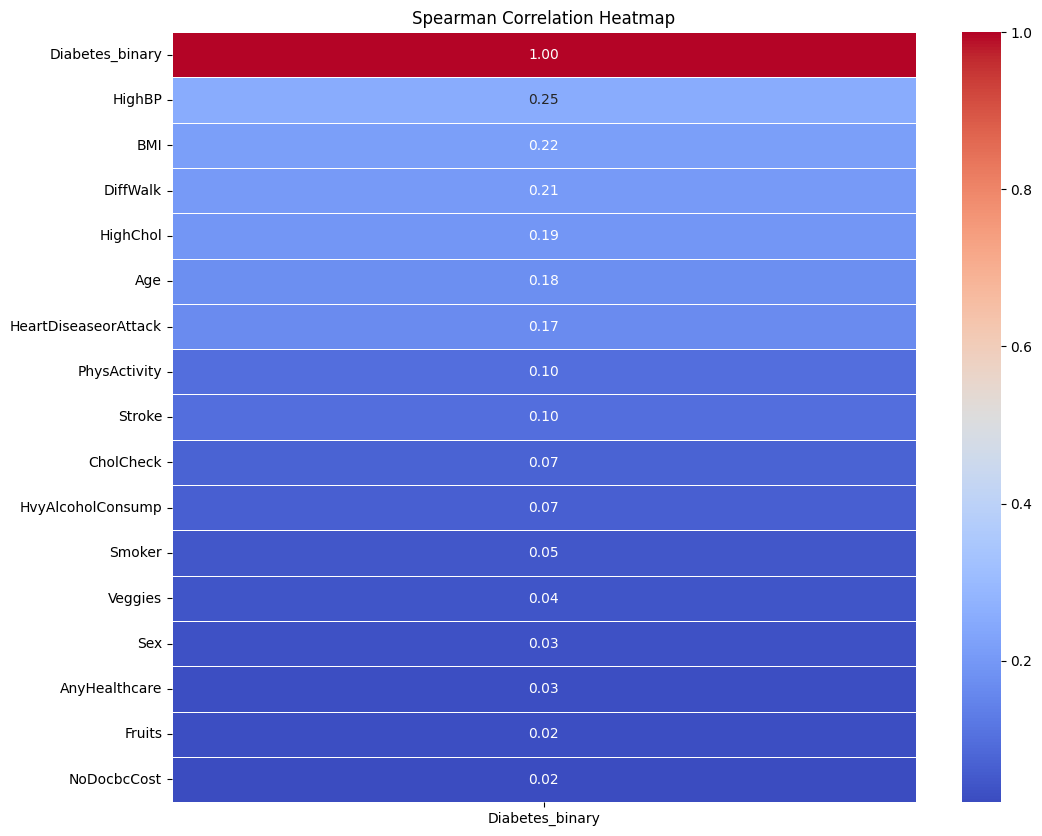

In [100]:
corr_pearso = df_data.corr(method='spearman')[['Diabetes_binary']].abs().sort_values(by='Diabetes_binary', ascending=False)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearso, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

### Analyse exploratoire qualitative (EDA visuelle)


L'objectif est ici de visualiser graphiquement les distributions et les relations entre variables afin de dégager des tendances interprétables. Nous allons nous concentrer uniquement sur l'unique variable quantitative (BMI) car les autres variables sont catégorielles.

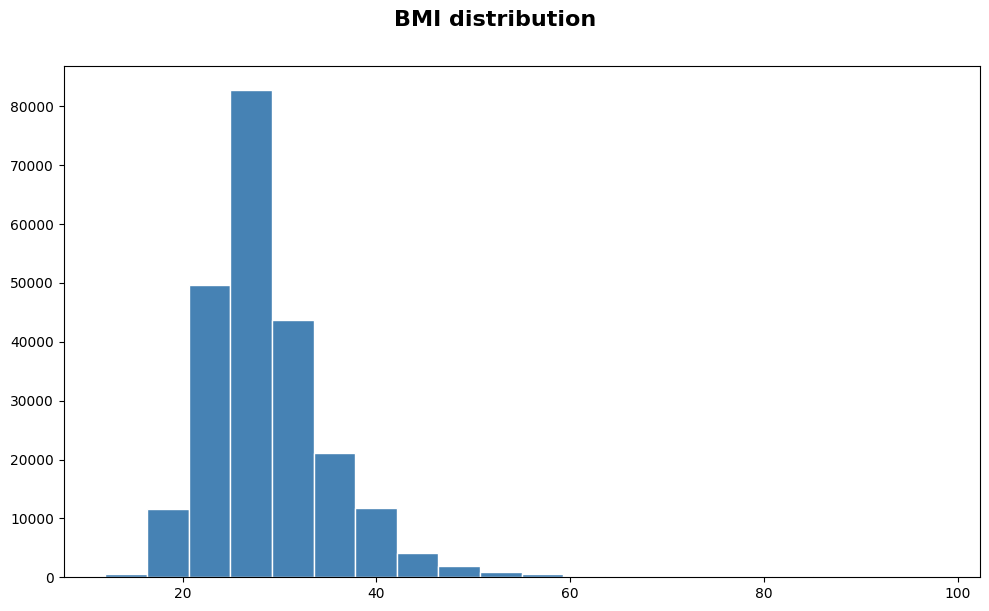

In [101]:
# Distribution de chaque variable
df_data['BMI'].hist(figsize=(10, 6), bins=20, color='steelblue', edgecolor='white', grid=False)
plt.suptitle("BMI distribution", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Nous pouvons voir que la distribution de la variable BMI n'est pas normale, elle est plutôt asymétrique. Cela nous permettra de nous orienter vers des méthodes de pré-traitement adapté à ce type de distribution.

Les graphiques de boite à moustache (boxplot) permettent de visualiser la distribution d'une variable quantitative (BMI) en fonction d'une variable catégorielle (Diabetes_binary). Ils montrent la médiane, les quartiles et les valeurs extrêmes.

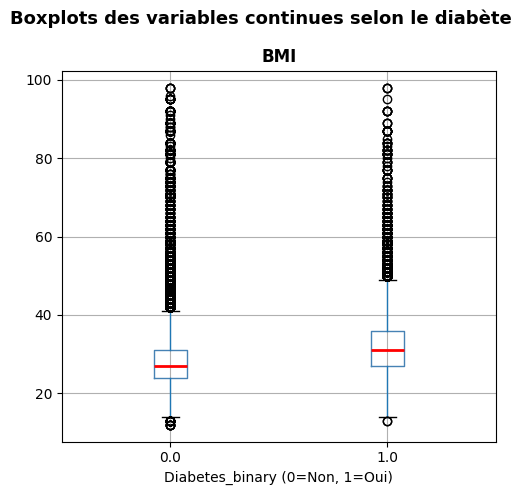

In [102]:
# Boxplots des variables continues selon Diabetes_binary
continuous_cols = ['BMI']

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(5 * len(continuous_cols), 5))
if len(continuous_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, continuous_cols):
    df_data.boxplot(column=col, by='Diabetes_binary', ax=ax,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Diabetes_binary (0=Non, 1=Oui)")

plt.suptitle("Boxplots des variables continues selon le diabète", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La variable BMI contient un grand nombre de valeurs extrêmes (outliers) qui peuvent potentiellement influencer négativement l'entraînement du modèle.  Nous savons désormais qu'il nous faut gérer impérativement ces valeurs aberrantes avant d'entraîner notre modèle.

### Traitement (main)

In [103]:
# Vérification des valeurs manquantes
columns_missing = check_missing_values(df_data)
if columns_missing:
    df_data = fill_missing_columns(df_data, columns_missing)

# Détection des outliers
df_data = outliers_detection(df_data)

# Normalisation
df_data = normalize_data(df_data)

# Split du dataset
train, temp = train_test_split(df_data, test_size=0.3, random_state=42)
validate, test = train_test_split(temp, test_size=0.5, random_state=42)

# Save du dataset nettoyé
df_data.to_csv("Health_Data/dataset_cleaned.csv", index=False)

No missing values found in the dataset.
Outliers removed! Lower bound: 12.0, Upper bound: 44.0


Maintenant que nous avons effectué un traitement complet de nos données, nous analyser les données après le pré-traitement afin de vérifier que les différentes étapes ont été correctement appliquées et que les données sont prêtes pour l'entraînement du modèle.

In [104]:
# Résumé statistique post-traitement
print("=== Statistiques descriptives ===")
display(df_data.describe().T.style.background_gradient(cmap='Blues'))

=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,223836.000000,0.147881,0.354982,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,223836.000000,0.449445,0.497439,0.000000,0.000000,0.000000,1.000000,1.000000
HighChol,223836.000000,0.440675,0.496469,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,223836.000000,0.959091,0.198081,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,223836.000000,0.502446,0.169118,0.000000,0.375000,0.468750,0.593750,1.000000
Smoker,223836.000000,0.466605,0.498885,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,223836.000000,0.044649,0.206532,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,223836.000000,0.102870,0.303790,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,223836.000000,0.738116,0.439661,0.000000,0.000000,1.000000,1.000000,1.000000
Fruits,223836.000000,0.614705,0.486666,0.000000,0.000000,1.000000,1.000000,1.000000


La variable BMI à été normalisée entre 0 et 1, ce qui évitera à notre modèle d'être biaisé par l'échelle des données et lui permettra d'apprendre plus efficacement. 